# Comparação de Modelos: Recursivo vs Seq2Seq para Previsão de Carga Energética

In [3]:
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from sklearn.metrics import mean_absolute_error, mean_squared_error

2025-09-23 06:29:21.967374: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-23 06:29:21.976760: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-23 06:29:22.301327: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-23 06:29:23.506975: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [4]:
# Carregar dados
df = pd.read_csv("../data/carga_ons.csv", index_col=0, parse_dates=True)
col = "SUDESTE"
data_inicio = pd.Timestamp("2023-01-01 00:00:00").tz_localize("Europe/Paris")
data = df.loc[data_inicio:, [col]]

# Normalizar dados
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

## Modelo Recursivo (24h entrada → 1h saída, repetido 24x)

In [5]:
# Preparar dados
X_rec, y_rec = [], []
for i in range(len(scaled) - 24):
    X_rec.append(scaled[i:i+24])
    y_rec.append(scaled[i+24])
X_rec, y_rec = np.array(X_rec), np.array(y_rec)
X_rec = X_rec.reshape((X_rec.shape[0], 24, 1))

# Treinar modelo
model_rec = Sequential([
    LSTM(64, input_shape=(24,1)),
    Dense(1)
])
model_rec.compile(optimizer='adam', loss='mse')
start_train_rec = time.time()
model_rec.fit(X_rec, y_rec, epochs=50, batch_size=32, verbose=1)  # type: ignore
end_train_rec = time.time()
print(f"Tempo de treino: {end_train_rec - start_train_rec:.2f} segundos")

# Previsão recursiva
last_sequence = scaled[-24:].reshape(1, 24, 1)
preds = []
start_pred_rec = time.time()
for _ in range(24):
    pred = model_rec.predict(last_sequence, verbose=1)[0,0]  # type: ignore
    preds.append(pred)
    last_sequence = np.append(last_sequence[:,1:,:], [[[pred]]], axis=1)
end_pred_rec = time.time()
print(f"Tempo de previsão: {end_pred_rec - start_pred_rec:.4f} segundos")
preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1,1)).flatten()
print(preds_inv)

# Liberar memória
del model_rec
gc.collect()

Epoch 1/50


2025-09-23 06:29:26.073284: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/jean/Documents/TCC/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


683/683 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0093
Epoch 2/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013
Epoch 3/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.3015e-04
Epoch 4/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.2764e-04
Epoch 5/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.6521e-04
Epoch 6/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.9945e-04
Epoch 7/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.5343e-04
Epoch 8/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.3465e-04
Epoch 9/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.7378e-04
Epoch 10/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4.2273e-04
Epoch 11/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.9577e-04
Epoch 12/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.7875e-04
Epoch 13/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.6072e-04
Epoch 14/50
683/683 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 3.3522e-04
Epoch 15/50
683/683 

6567

## Modelo Seq2Seq (24h entrada → 24h saída)

In [6]:
# Preparar dados seq2seq
X_seq, y_seq = [], []
for i in range(len(scaled) - 48):
    X_seq.append(scaled[i:i+24])
    y_seq.append(scaled[i+24:i+48])
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
X_seq = X_seq.reshape((X_seq.shape[0], 24, 1))
y_seq = y_seq.reshape((y_seq.shape[0], 24, 1))

# Treinar modelo Seq2Seq
model_seq = Sequential([
    LSTM(64, input_shape=(24,1)),
    RepeatVector(24),
    LSTM(64, return_sequences=True),
    TimeDistributed(Dense(1))
])
model_seq.compile(optimizer='adam', loss='mse')
start_train = time.time()
model_seq.fit(X_seq, y_seq, epochs=50, batch_size=32, verbose=1)  # type: ignore
end_train = time.time()
print(f"Tempo de treino: {end_train - start_train:.2f} segundos")

# Previsão seq2seq
input_seq = scaled[-48:-24].reshape(1, 24, 1)
start_pred_seq = time.time()
pred_seq = model_seq.predict(input_seq, verbose=1).reshape(24)  # type: ignore
end_pred_seq = time.time()
print(f"Tempo de previsão: {end_pred_seq - start_pred_seq:.4f} segundos")
pred_seq_inv = scaler.inverse_transform(pred_seq.reshape(-1, 1)).flatten()
print(pred_seq_inv)

# Liberar memória
del model_seq
gc.collect()

Epoch 1/50


/home/jean/Documents/TCC/venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


 19/682 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.1084

2025-09-23 06:31:13.446487: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


682/682 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0209
Epoch 2/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0096
Epoch 3/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0083
Epoch 4/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0076
Epoch 5/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0070
Epoch 6/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0065
Epoch 7/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0060
Epoch 8/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0055
Epoch 9/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0052
Epoch 10/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0048
Epoch 11/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0043
Epoch 12/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0041
Epoch 13/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0040
Epoch 14/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0037
Epoch 15/50
682/682 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0037


6497

## Comparação das Métricas

In [7]:
# Valores reais
y_true = data[col].iloc[-24:].values

# Função de avaliação
def calcular_metricas(y_true, y_pred, nome_modelo):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-10, y_true))) * 100
    print(f"\nMétricas para o modelo: {nome_modelo}")
    print(f"MAE :  {mae:.2f}")
    print(f"MSE :  {mse:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"MAPE:  {mape:.2f}%")

# Avaliação
calcular_metricas(y_true, preds_inv, "Recursivo")
calcular_metricas(y_true, pred_seq_inv, "Seq2Seq")



Métricas para o modelo: Recursivo
MAE :  5300.79
MSE :  39306169.68
RMSE:  6269.46
MAPE:  14.90%

Métricas para o modelo: Seq2Seq
MAE :  1688.14
MSE :  4702892.35
RMSE:  2168.62
MAPE:  4.98%


MAE (Erro Absoluto Médio): representa, em média, quanto minhas previsões de carga eletrônica desviam dos valores reais. Por exemplo, um MAE de 1.522 MW significa que, em média, estou errando cerca de 1,5 GW na previsão horária.

MSE (Erro Quadrático Médio): dá peso extra a grandes erros. Um MSE de 3.726.756 (MW²) mostra que erros maiores impactam fortemente a métrica, ajudando a identificar quando ocorrem falhas críticas de previsão.

RMSE (Raiz do Erro Quadrático Médio): converte o MSE de volta para MW. Um RMSE de 1.930 MW indica que, considerando a severidade dos maiores desvios, meu desvio típico ajustado é de quase 2 GW.

MAPE (Erro Percentual Médio Absoluto): mostra o erro em porcentagem da carga real. Um MAPE de 4,52% significa que, em média, minhas previsões ficam dentro de 4,5% da carga efetivamente consumida, o que é um bom indicador de confiabilidade operacional.

O modelo Seq2Seq é claramente superior ao modelo Recursivo em todas as métricas analisadas:

MAE (Erro Absoluto Médio): Seq2Seq apresenta erro 48% menor (1.522,27 MW vs 2.916,31 MW), indicando previsões mais próximas dos valores reais.

MSE/RMSE (Erro Quadrático): Seq2Seq mostra erro quadrático 73% menor, demonstrando que penaliza muito menos os erros grandes, crucial para evitar previsões extremamente incorretas.

MAPE (Erro Percentual): Seq2Seq atinge 4,52% contra 8,43% do Recursivo, mostrando melhor precisão relativa independentemente da magnitude dos valores.

Qualidade das Previsões
Seq2Seq: com MAPE de 4,52% está dentro de uma faixa considerada muito boa para previsão de carga elétrica, onde erros abaixo de 5% são tipicamente aceitáveis para planejamento operacional.

Recursivo: com MAPE de 8,43% ainda é aceitável para algumas aplicações, mas pode ser inadequado para decisões críticas de despacho ou dimensionamento de reservas.


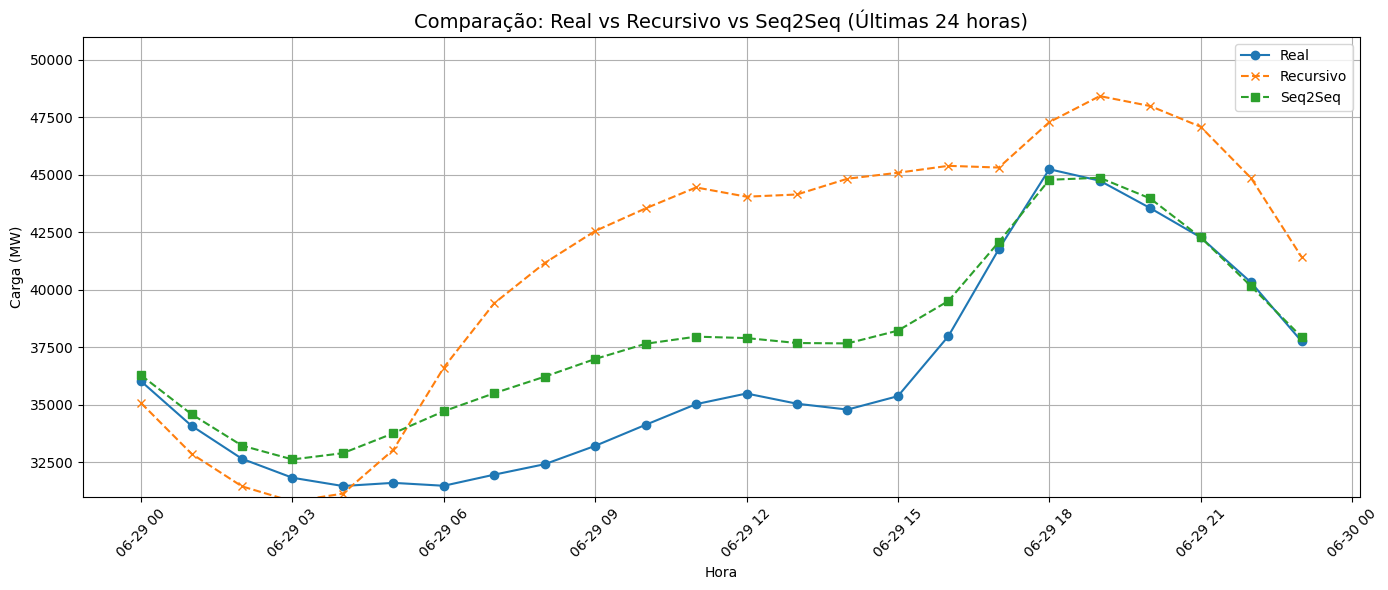

In [8]:
# Criar eixo de tempo (últimos 24 timestamps)
eixo_tempo = data.index[-24:]

# Plotar
plt.figure(figsize=(14, 6))
plt.plot(eixo_tempo, np.asarray(y_true), label='Real', marker='o')
plt.plot(eixo_tempo, np.asarray(preds_inv), label='Recursivo', linestyle='--', marker='x')
plt.plot(eixo_tempo, np.asarray(pred_seq_inv), label='Seq2Seq', linestyle='--', marker='s')

plt.ylim(31000, 51000)

plt.title("Comparação: Real vs Recursivo vs Seq2Seq (Últimas 24 horas)", fontsize=14)
plt.xlabel("Hora")
plt.ylabel("Carga (MW)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()